In [1]:
# -----------------------------------------------------------
# 1. Importar librerías
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [2]:

# -----------------------------------------------------------
# 2. Crear datos de ejemplo (tres grupos)
# -----------------------------------------------------------
np.random.seed(0)

grupo1 = np.random.normal(loc=[2, 2], scale=0.3, size=(50, 2))
grupo2 = np.random.normal(loc=[6, 6], scale=0.4, size=(50, 2))
grupo3 = np.random.normal(loc=[2, 7], scale=0.5, size=(50, 2))

data = np.vstack([grupo1, grupo2, grupo3])
df = pd.DataFrame(data, columns=['x', 'y'])


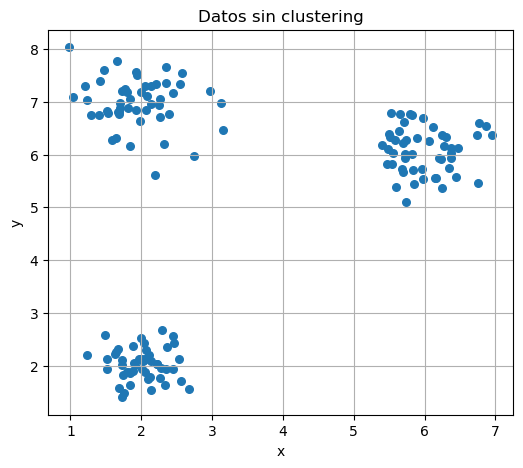

In [3]:

# -----------------------------------------------------------
# 3. Graficar datos sin cluster
# -----------------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(df['x'], df['y'], s=30)
plt.title("Datos sin clustering")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


In [4]:

# -----------------------------------------------------------
# 4. Normalizar los datos (OBLIGATORIO para DBSCAN)
# -----------------------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(df[['x', 'y']])
print(X)


[[-0.40703398 -1.32887967]
 [-0.52876047 -1.07673461]
 [-0.39099024 -1.51756151]
 [-0.53320125 -1.40442643]
 [-0.69646758 -1.32744942]
 [-0.65814104 -1.18448622]
 [-0.56250478 -1.36702632]
 [-0.61166794 -1.33798653]
 [-0.44888079 -1.41179613]
 [-0.63194171 -1.50068795]
 [-1.0761907  -1.29416038]
 [-0.54647765 -1.48535562]
 [-0.32864835 -1.58291327]
 [-0.67337557 -1.40933398]
 [-0.44288213 -1.18241983]
 [-0.6564509  -1.33189251]
 [-0.81807821 -1.65502406]
 [-0.73439591 -1.36227666]
 [-0.48976892 -1.21899076]
 [-0.74050532 -1.42510303]
 [-0.8429977  -1.5782083 ]
 [-0.94494618 -1.11647511]
 [-0.75946618 -1.4437011 ]
 [-0.87465599 -1.27719236]
 [-0.93062814 -1.41283472]
 [-0.81926877 -1.33069531]
 [-0.75964489 -1.5454171 ]
 [-0.68483664 -1.32502029]
 [-0.6701579  -1.34226066]
 [-0.77879046 -1.43338192]
 [-0.78470203 -1.43294523]
 [-0.80650883 -1.6201606 ]
 [-0.65296662 -1.43872961]
 [-0.93315478 -1.32030125]
 [-0.82110274 -1.37657792]
 [-0.5674567  -1.36602528]
 [-0.50385719 -1.55284057]
 

In [5]:

# -----------------------------------------------------------
# 5. Aplicar DBSCAN
# -----------------------------------------------------------
# eps → radio de vecindad
# min_samples → mínimo de puntos para formar un cluster
db = DBSCAN(eps=0.3, min_samples=20)

labels = db.fit_predict(X)
print(labels)
df["cluster"] = labels
print(df)


[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  2  2  2  2  2  2  2  2  2 -1  2  2  2  2  2  2  2  2 -1  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2 -1 -1  2  2 -1  2  2  2  2
  2  2 -1  2  2  2]
            x         y  cluster
0    2.529216  2.120047        0
1    2.293621  2.672268        0
2    2.560267  1.706817        0
3    2.285027  1.954593        0
4    1.969034  2.123180        0
..        ...       ...      ...
145  1.685956  6.759486        2
146  3.151958  6.469992       -1
147  1.932025  7.568446        2
148  2.048862  7.291477        2
149  1.800275  7.185028        2

[150 rows x 3 columns]


In [6]:

# -----------------------------------------------------------
# 6. Mostrar resultados
# -----------------------------------------------------------
print("Clusters encontrados:", set(labels))
print("\nDonde -1 significa 'ruido' (outliers detectados por DBSCAN)")

df.head()


Clusters encontrados: {0, 1, 2, -1}

Donde -1 significa 'ruido' (outliers detectados por DBSCAN)


,x,y,cluster
0,2.529216,2.120047,0
1,2.293621,2.672268,0
2,2.560267,1.706817,0
3,2.285027,1.954593,0
4,1.969034,2.123180,0


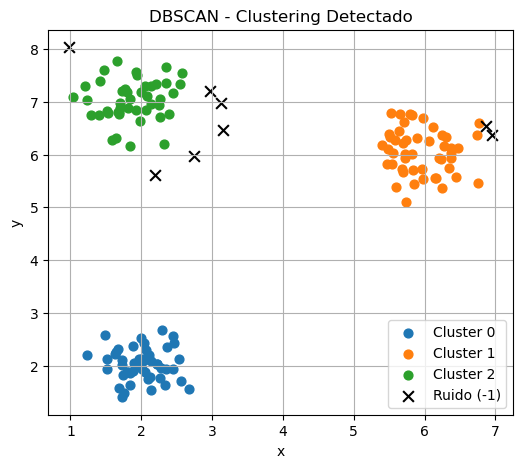

In [7]:

# -----------------------------------------------------------
# 7. Graficar clusters resultado
# -----------------------------------------------------------
plt.figure(figsize=(6,5))

# Noise en color negro
colors = ['red','blue','green','purple','orange','brown']

for cluster_id in set(labels):
    cluster_points = df[df['cluster'] == cluster_id]

    # puntos ruido
    if cluster_id == -1:
        plt.scatter(cluster_points['x'], cluster_points['y'], 
                    label="Ruido (-1)", color="black", s=60, marker="x")
    else:
        plt.scatter(cluster_points['x'], cluster_points['y'], 
                    label=f"Cluster {cluster_id}", s=40)

plt.title("DBSCAN - Clustering Detectado")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
